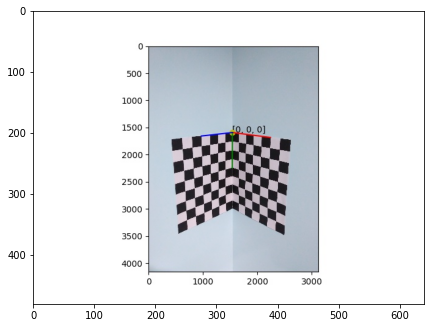

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import random
from matplotlib.patches import ConnectionPatch
import glob
import random

world_points_chessboard=[(1,0,1),(1,0,5),(1,0,8),(2,0,4),(2,0,6),(3,0,2),(4,0,3),(4,0,7),(6,0,6),(7,0,4),
(0,1,3),(0,2,5),(0,2,8),(0,2,4),(0,2,6),(0,3,2),(0,4,3),(0,4,7),(0,5,5),(0,6,3)]

image_points_chessboard=[(1663,1780),(1659,2442),(1657,2906),(1782,2320),(1778,2648),(1929,2011),(2063,2232),(2045,2924),(2364,2882),(2551,2565),
(1408,2113),(1299,2475),(1298,2962),(1284,2321),(1300,2637),(1140,2011),(1000,2221),(1023,2918),(861,2627),(666,2303)]

world_points=world_points_chessboard
image_points=image_points_chessboard

all_world_points=[]
for i in range (0,8):
    for k in range(0,10):
        all_world_points.append((i,0,k))

for j in range (1,8):
    for k in range (0,10):
        all_world_points.append((0,j,k))

image=plt.imread('../images/Section-1/calib-object.jpg')
legend=plt.imread('../images/Section-1/calib-object-legend.jpg')
plt.figure(figsize=(7,7))
plt.imshow(legend)
plt.show()

# Task-1: Direct Linear Transformation

## Assumptions
- Red line: x axis
- Blue line: y axis
- Green line: z axis
- Reprojection Error is calculated using RMSE

## Implementation

### Calculating Projection Matrix
- We are given the 3D world points and their corresponding 2D image points which are related by the equation $x = P X$ where $x$ is the 2D image point, $P$ is the projection matrix and $X$ is the 3D world point.
- For every image point $x_i$ and corresponding world point $X_i$, we can write the equation $x_i = P X_i$.
- This gives us 2 equations, one for u and one for v.  
- We have 12 unknowns so we require minimum 6 points as each points gives 2 equations
- We write P as a column vector and stack the equations to get a 12x12 matrix and equate it to 0 vector to get the form $A P = 0$.
- This we solve using SVD to get the projection matrix $P$.

**Note**: We usually take more than 6 points to get a better estimate of the projection matrix as there might be noise in our measurments.

### Calculating Reprojection Error
- We calculte $ P X $ for every world point and compare it with the actual image point to get the error.
  
### Calculating K,R and C
- We can decompose $P$ as $P = [ KR |- KRC ]$.
- Let $H = KR$ and $h = -KRC$.
- We multiply the inverse of H with h to get the projection center $C$.
- $R$ and $K$ can be obtained by decomposing inverse of H using QR decomposition.

In [5]:
def P_Matrix(dim1,dim2,indices):
    A=[]
    for i in range(len(indices)):    
        x=world_points[indices[i]][0]
        y=world_points[indices[i]][1]
        z=world_points[indices[i]][2]
        u=image_points[indices[i]][0]
        v=image_points[indices[i]][1]
        x=x*dim1
        y=y*dim1
        z=z*dim2
        A.append([x,y,z,1,0,0,0,0,-u*x,-u*y,-u*z,-u])
        A.append([0,0,0,0,x,y,z,1,-v*x,-v*y,-v*z,-v])
    A=np.array(A)
    U,S,V=np.linalg.svd(A)
    P = V[-1, :]
    P = P.reshape(3,4)
    if P[-1,-1]!=0:
        P=P/P[-1,-1]

    return P

def projection_error(P,dim1,dim2,indices):
    error=0
    for i in range(len(indices)):
        x,y,z=world_points[indices[i]]
        u,v=image_points[indices[i]]
        x=x*dim1
        y=y*dim1
        z=z*dim2
        p=np.array([x,y,z,1])
        p=P.dot(p)
        if p[2]!=0:
            p=p/p[2]
        error+=(u-p[0])**2+(v-p[1])**2
    error=error/len(indices)
    error=np.sqrt(error)
    return error


In [6]:
def getKRC(P):
    H=P[:,0:3]
    h=P[:,-1]
    C=np.linalg.inv(H).dot(h)
    C=-C

    R,K=np.linalg.qr(np.linalg.inv(H))
    R=R.T
    K=np.linalg.inv(K)
    if K[-1,-1]!=0:
        K=K/K[-1,-1]
    return K,R,C

In [7]:
def mapping_world_points(P,dim1,dim2,indices):
    new_image_points=[]
    for i in range(len(indices)):
        x,y,z=world_points[indices[i]]
        x=x*dim1
        y=y*dim1
        z=z*dim2
        p=np.array([x,y,z,1])
        p=P.dot(p)
        if p[2]!=0:
            p=p/p[2]
        new_image_points.append(p)
    return new_image_points    

def plot_wireframe(projections, image):
    '''
    projections: n_samples X 2 ((height * width) X 2D point coordinate)
    image: on which wireframe has to be plotted
    '''
    # Plotting image points on the image
    plt.scatter(projections[:, 0], projections[:, 1], color='r', s=13, lw=1)

    for i in range(0,150,10):
        plt.plot([projections[i, 0], projections[i+9, 0]], [projections[i, 1], projections[i+9, 1]], color='r')
    # plot horizontal lines
    for i in range(0,10):
        plt.plot([projections[i, 0], projections[i+70, 0]], [projections[i, 1], projections[i+70, 1]], color='r')
        plt.plot([projections[i, 0], projections[i+140, 0]], [projections[i, 1], projections[i+140, 1]], color='r') 
    
    plt.imshow(image)

## Experiment-1 

Assume scale of each chessblock = 28mmx28mm and use all the 20 (or more) points which you have marked

P matrix
[[ 2.57099196e+00 -6.05044081e+00  5.36241304e-01  1.53648429e+03]
 [-1.08989745e+00 -1.16987903e+00  6.58245488e+00  1.58817797e+03]
 [-1.09423151e-03 -1.09639137e-03  3.31591582e-04  1.00000000e+00]]

projection error (pixels)
4.834298834072634

K matrix
[[-3.84668169e+03 -3.97671861e+01  1.59331004e+03]
 [-0.00000000e+00 -3.85227375e+03  1.85621601e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

R matrix
[[-0.70644265  0.70771546  0.00881   ]
 [-0.15424017 -0.14179054 -0.97780643]
 [-0.69075955 -0.69212302  0.20932504]]

C matrix
[449.1003096  436.86847493 -89.27086172]

projected points
[array([1.65891107e+03, 1.77997911e+03, 1.00000000e+00]), array([1.65738512e+03, 2.44068000e+03, 1.00000000e+00]), array([1.65631192e+03, 2.90534710e+03, 1.00000000e+00]), array([1.78357199e+03, 2.32038987e+03, 1.00000000e+00]), array([1.78046482e+03, 2.64774295e+03, 1.00000000e+00]), array([1.92356342e+03, 2.01288151e+03, 1.00000000e+00]), array([2.06503937e+03, 2.23023991e+03, 1

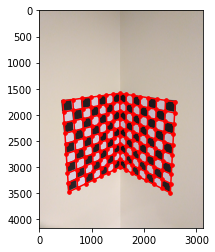

In [8]:
# Experiment-1: scale=28mm X 28mm
indices=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]
world_points=world_points_chessboard

P=P_Matrix(28,28,indices)
print("P matrix")
print(P)
print("\nprojection error (pixels)")
print(projection_error(P,28,28,indices))
K,R,C=getKRC(P)
print("\nK matrix")
print(K)
print("\nR matrix")
print(R)
print("\nC matrix")
print(C)
projected_points=mapping_world_points(P,28,28,indices)
print("\nprojected points")
print(projected_points)

world_points=all_world_points
all_projected_points=mapping_world_points(P,28,28,[i for i in range(len(world_points))])
plot_wireframe(np.array(all_projected_points),image)


## Experiment-2

Assume scale of each chessblock = 2800mmx2800mm and use all the 20 (or more) points which you have marked



P matrix
[[ 2.57099174e-02 -6.05044066e-02  5.36241012e-03  1.53648429e+03]
 [-1.08989758e-02 -1.16987887e-02  6.58245428e-02  1.58817799e+03]
 [-1.09423153e-05 -1.09639128e-05  3.31591391e-06  1.00000000e+00]]

projection error (pixels)
4.834298971849666

K matrix
[[-3.84668181e+03 -3.97671455e+01  1.59330991e+03]
 [-0.00000000e+00 -3.85227379e+03  1.85621558e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

R matrix
[[-0.70644261  0.70771549  0.00880998]
 [-0.15424009 -0.14179047 -0.97780645]
 [-0.69075961 -0.692123    0.20932493]]

C matrix
[44910.03369798 43686.84853599 -8927.08680634]

projected points
[array([1.65891107e+03, 1.77997912e+03, 1.00000000e+00]), array([1.65738512e+03, 2.44068000e+03, 1.00000000e+00]), array([1.65631193e+03, 2.90534711e+03, 1.00000000e+00]), array([1.78357199e+03, 2.32038987e+03, 1.00000000e+00]), array([1.78046482e+03, 2.64774294e+03, 1.00000000e+00]), array([1.92356341e+03, 2.01288150e+03, 1.00000000e+00]), array([2.06503937e+03, 2.2302399

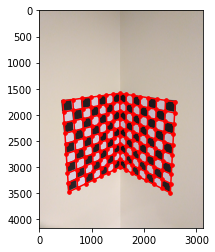

In [9]:
indices=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]
world_points=world_points_chessboard

P=P_Matrix(2800,2800,indices)
print("\n\nP matrix")
print(P)
print("\nprojection error (pixels)")
print(projection_error(P,2800,2800,indices))
K,R,C=getKRC(P)
print("\nK matrix")
print(K)
print("\nR matrix")
print(R)
print("\nC matrix")
print(C)
projected_points=mapping_world_points(P,2800,2800,indices)
print("\nprojected points")
print(projected_points)

world_points=all_world_points
all_projected_points=mapping_world_points(P,2800,2800,[i for i in range(len(world_points))])
plot_wireframe(np.array(all_projected_points),image)

## Experiment-3

Assume scale of each chessblock = 28mmx56mm and use all the 20 (or more) points which you have marked



P matrix
[[ 2.57099185e+00 -6.05044076e+00  2.68120564e-01  1.53648429e+03]
 [-1.08989750e+00 -1.16987906e+00  3.29122725e+00  1.58817798e+03]
 [-1.09423152e-03 -1.09639138e-03  1.65795735e-04  1.00000000e+00]]

projection error (pixels)
4.834298936509538

K matrix
[[-3.91103430e+03 -7.19503204e+01  1.59249916e+03]
 [-0.00000000e+00 -1.99181759e+03  1.24476116e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

R matrix
[[-0.70636041  0.70763308  0.01761795]
 [-0.08770965 -0.06280018 -0.99416455]
 [-0.70239731 -0.70378375  0.10642581]]

C matrix
[ 449.10031192  436.86847409 -178.54172676]

projected points
[array([1.65891107e+03, 1.77997911e+03, 1.00000000e+00]), array([1.65738512e+03, 2.44068000e+03, 1.00000000e+00]), array([1.65631192e+03, 2.90534711e+03, 1.00000000e+00]), array([1.78357199e+03, 2.32038987e+03, 1.00000000e+00]), array([1.78046482e+03, 2.64774294e+03, 1.00000000e+00]), array([1.92356342e+03, 2.01288151e+03, 1.00000000e+00]), array([2.06503937e+03, 2.23023991e+

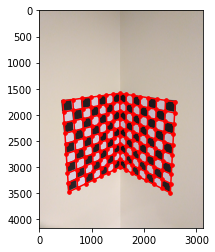

In [10]:
indices=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]
world_points=world_points_chessboard

P=P_Matrix(28,56,indices)
print("\n\nP matrix")
print(P)
print("\nprojection error (pixels)")
print(projection_error(P,28,56,indices))
K,R,C=getKRC(P)
print("\nK matrix")
print(K)
print("\nR matrix")
print(R)
print("\nC matrix")
print(C)
projected_points=mapping_world_points(P,28,56,indices)
print("\nprojected points")
print(projected_points)

world_points=all_world_points
all_projected_points=mapping_world_points(P,28,56,[i for i in range(len(world_points))])
plot_wireframe(np.array(all_projected_points),image)

## Experiment-4

Assume scale of each chessblock = 28mmx28mm and use only 10 points out of the 20 (or more) which you have marked (Make sure that all these 10
points do not lie on the same plane)

[ 0  2  3  5  8  9 10 12 17 19]


P matrix
[[ 2.73058437e+00 -6.05426491e+00  5.50272441e-01  1.53455657e+03]
 [-9.43164990e-01 -1.14903472e+00  6.64592318e+00  1.58304441e+03]
 [-1.03886278e-03 -1.08877709e-03  3.41364635e-04  1.00000000e+00]]

projection error (pixels)
3.436000188365375

K matrix
[[-3.98821812e+03 -6.18854287e+01  1.65583905e+03]
 [-0.00000000e+00 -3.98825155e+03  1.88961132e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

R matrix
[[-0.72062882  0.69309858  0.01756302]
 [-0.16571785 -0.14759221 -0.97506622]
 [-0.67322485 -0.70557133  0.22121801]]

C matrix
[458.17614702 451.46745289 -95.11950647]

projected points
[array([1.65881718e+03, 1.77743485e+03, 1.00000000e+00]), array([1.65582508e+03, 2.90756917e+03, 1.00000000e+00]), array([1.78469279e+03, 2.32085652e+03, 1.00000000e+00]), array([1.92599364e+03, 2.01318488e+03, 1.00000000e+00]), array([2.36258782e+03, 2.87839751e+03, 1.00000000e+00]), array([2.55372806e+03, 2.56708253e+03, 1.00000000e+00]), array(

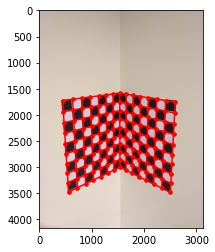

In [11]:
world_points=world_points_chessboard
n=np.random.randint(1,9)
indices=np.random.choice(10,n,replace=False)
indices=np.append(indices,np.random.choice(10,10-n,replace=False)+10)
indices.sort()
print(indices)
P=P_Matrix(28,28,indices)
print("\n\nP matrix")
print(P)
print("\nprojection error (pixels)")
print(projection_error(P,28,28,indices))
K,R,C=getKRC(P)
print("\nK matrix")
print(K)
print("\nR matrix")
print(R)
print("\nC matrix")
print(C)
projected_points=mapping_world_points(P,28,28,indices)
print("\nprojected points")
print(projected_points)

world_points=all_world_points
all_projected_points=mapping_world_points(P,28,28,[i for i in range(len(world_points))])
plot_wireframe(np.array(all_projected_points),image)

## Experiment-5

Assume scale of each chessblock = 28mmx28mm and use only 6 points out of the 20 (or more) which you have marked (Make sure that all these 6
points do not lie on the same plane)

3
[ 1  3  4 13 14 17]


P matrix
[[ 9.59432272e-01 -7.12141236e+00  1.34491871e+00  1.53049900e+03]
 [-3.31125032e+00 -2.27423899e+00  7.78489208e+00  1.57274849e+03]
 [-2.06270781e-03 -1.61175754e-03  7.93413288e-04  1.00000000e+00]]

projection error (pixels)
1.893664650111632

K matrix
[[-2.26906834e+03  3.22540878e+00  1.41218857e+03]
 [-0.00000000e+00 -2.30029206e+03  2.22831229e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

R matrix
[[-0.624196    0.78036607 -0.03752528]
 [-0.20424269 -0.20935283 -0.95627209]
 [-0.75409832 -0.58923695  0.29006126]]

C matrix
[285.16219221 251.98908111  -7.11913493]

projected points
[array([1.65728206e+03, 2.43982208e+03, 1.00000000e+00]), array([1.78235675e+03, 2.32108170e+03, 1.00000000e+00]), array([1.77854778e+03, 2.64809250e+03, 1.00000000e+00]), array([1.28412362e+03, 2.32053880e+03, 1.00000000e+00]), array([1.30163057e+03, 2.63965538e+03, 1.00000000e+00]), array([1.02206451e+03, 2.91681584e+03, 1.00000000e+00])]


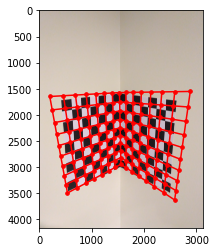

In [12]:
world_points=world_points_chessboard
n=np.random.randint(1,6)
print(n)
indices=np.random.choice(10,n,replace=False)
indices=np.append(indices,np.random.choice(10,6-n,replace=False)+10)
indices.sort()
print(indices)
P=P_Matrix(28,28,indices)
print("\n\nP matrix")
print(P)
print("\nprojection error (pixels)")
print(projection_error(P,28,28,indices))
K,R,C=getKRC(P)
print("\nK matrix")
print(K)
print("\nR matrix")
print(R)
print("\nC matrix")
print(C)
projected_points=mapping_world_points(P,28,28,indices)
print("\nprojected points")
print(projected_points)

world_points=all_world_points
all_projected_points=mapping_world_points(P,28,28,[i for i in range(len(world_points))])
plot_wireframe(np.array(all_projected_points),image)

## Experiment-6

Assume scale of each chessblock = 28mmx28mm and use only 10 points out of the 20 (or more) which you have marked, and choose points such that all these 10 points lie on the same plane

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


P matrix
[[ 3.08780016e+00 -3.31900551e+11  4.57267735e-01  1.53517659e+03]
 [-5.68020910e-01 -6.81124797e+14  6.47693759e+00  1.57348611e+03]
 [-9.70464918e-04 -4.09990122e+27  3.46259980e-04  1.00000000e+00]]

projection error (pixels)
26.902442214271193

K matrix
[[-7.57077928e-28 -4.51334151e-29  8.09533043e-17]
 [-0.00000000e+00 -1.57973623e-27  1.66132002e-13]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

R matrix
[[-9.96176484e-01  2.28421061e-31 -8.73636754e-02]
 [ 8.73636754e-02 -9.99696347e-33 -9.96176484e-01]
 [-2.28421061e-31 -1.00000000e+00 -9.99696347e-33]]

C matrix
[-4.55285817e+02  3.27786955e-28 -2.82864849e+02]

projected points
[array([1.66351293e+03, 1.76986909e+03, 1.00000000e+00]), array([1.65049143e+03, 2.41294882e+03, 1.00000000e+00]), array([1.64135630e+03, 2.86409599e+03, 1.00000000e+00]), array([1.78712382e+03, 2.30293901e+03, 1.00000000e+00]), array([1.77811196e+03, 2.61978012e+03, 1.00000000e+00]), array([1.94073365e

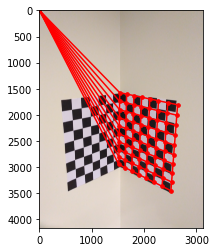

In [13]:
world_points=world_points_chessboard
k=np.random.choice(2,1,replace=False)
if k==0:
    indices=[0,1,2,3,4,5,6,7,8,9]
else:
    indices=[10,11,12,13,14,15,16,17,18,19]
print(indices)
P=P_Matrix(28,28,indices)
print("\n\nP matrix")
print(P)
print("\nprojection error (pixels)")
print(projection_error(P,28,28,indices))
K,R,C=getKRC(P)
print("\nK matrix")
print(K)
print("\nR matrix")
print(R)
print("\nC matrix")
print(C)
projected_points=mapping_world_points(P,28,28,indices)
print("\nprojected points")
print(projected_points)

world_points=all_world_points
all_projected_points=mapping_world_points(P,28,28,[i for i in range(len(world_points))])
plot_wireframe(np.array(all_projected_points),image)

world_points=world_points_chessboard

## Observations and Results for Task-1
- From the first three experiments, it can be seen that the scale of chessboard blocks has no effect on the projection error. This is because the projection error is calculated using the distance between the actual and the projected points. The scale of the chessboard blocks does not affect the distance between the actual and the projected points.
- In experiments 1 and 2 we see that the first 2 diagonal entries of K, which is an upper triangluar matrix, `K[0][0]` and `K[1][1]` are nearly the same which is as expected because the ratio of scale of chessboard blocks along the 2 directions is 1. Similarly we see that in experiment-3 the value of `K[0][0]` is almost twice of `K[1][1]` as the the ratio of scales is 2 in experiment-3.
- In experiments 4,5 it is observed that the reprojection error is generally higher than in experiments 1,2,3 where it is almost the same as we have only changed the scales in those cases. However, in experiments 4,5 we are taking only 10 and 6 points respectively to calculate projection matrix P and due to noise that is there in measurement of image coordinates, the error tends to be higher as well.
- In experiment 4,5 it is observed that the reprojection error increases as more and more points are taken from a single plane.
- The above point is even more clearly illustrated in experiment-6 where all 10 points are taken from a single plane. The error in this case is the highest and in case all points are taken from the y-z plane, the P matrix obtained has all its entries as 0 expect for `P[0][0]` which is equal to 1. Due to this the inverse of H matrix (the 3x3 submatrix of P) can't be taken and we get an error while calculating C.
- From the wireframes obtained in all the experiments it is observed that the wireframes in experiments 1,2,3 fit the chessboard points almost perfectly. In experiments 5,6 the wireframe grid becomes more distorted as it is unable to fit correctly all the points of chessboard. This is because fewer points are used in these experiments to calculate P matrix and hence due to noise in those points themselves, the values of the elements of P matrix get adjusted in such a way that it is unable to fit all the points perfectly.
- In experiment-6 the wireframe gets completely distorted which happens becasue we are taking 10 points from only a single plane to calculate P and so the P matrix obtained cannot project accurately the points from the other plane. This happens because while calculating P, in the equtaion $A P = 0$, the matrix A is rank deficient. 
### Question for Experiment-6
#### Q. Are these results similar to what you got for earlier experiments? If not, why is that the case? Is there any work around?
**Ans**: No the results obtained for experiment-6 are very different from the earlier experiments. In experiment-6 we get a very high reprojection error and the wireframe is completely distorted. This happens because we are taking 10 points from only a single plane to calculate P and so the P matrix obtained cannot project accurately the points from the other plane. This happens because while calculating P, in the equtaion $A P = 0$, the matrix A is rank deficient. There is no work around for this as we need to take points from multiple planes to get a good estimate of P. 


# Task-2: RANSAC

Implement a RANSAC-based variant of DLT and report results for Experiment-1 mentioned in the first section. 

## Implementation
- In every iteration we select 6 points out of the 20 randomly.
- Using those 6 points we calculate the P matrix and using that we map all the 20 world points to get the projected image points
- For each projected image point, we calculate the euclidean error and check if the error is within the threshold error that we have set. If so then we increment count of inliers.
- To get the best P matrix, the number of inliers should be maximum. So whenever we get more number of inliers than before we update the best P matrix.
- It might happen that over different iterations we might be getting the number of inliers equal to the maximum number of inliers obtained so far. In such a case we have to choose the matrix that gives least reprojection error.



P matrix
[[ 2.33115687e+00 -6.05317388e+00  2.91385094e-01  1.54084477e+03]
 [-1.26392591e+00 -1.33106265e+00  6.04787420e+00  1.61189891e+03]
 [-1.14518533e-03 -1.14210648e-03  1.81909016e-04  1.00000000e+00]]

projection error (pixels)
7.44783770934206

K matrix
[[-3.64470206e+03 -2.90799034e+01  1.62206611e+03]
 [-0.00000000e+00 -3.56676241e+03  1.53563160e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

R matrix
[[-0.70544735  0.70871076  0.00854933]
 [-0.08521051 -0.07283096 -0.99369755]
 [-0.70362149 -0.70172979  0.11176802]]

C matrix
[440.93064746 420.41990349 -81.8452882 ]

projected points
[array([1.65902267e+03, 1.79424332e+03, 1.00000000e+00]), array([1.65784944e+03, 2.43930573e+03, 1.00000000e+00]), array([1.65700063e+03, 2.90600165e+03, 1.00000000e+00]), array([1.78199884e+03, 2.31999604e+03, 1.00000000e+00]), array([1.78009959e+03, 2.64598681e+03, 1.00000000e+00]), array([1.91793887e+03, 2.01797327e+03, 1.00000000e+00]), array([2.05904208e+03, 2.23034603e+03, 

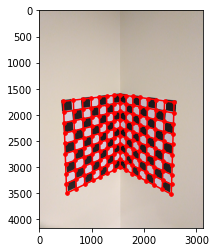

In [14]:
def RANSAC():
    error_threshold= 0.1
    max_iterations=1000
    max_inliers=-1
    num_samples=6
    best_P=np.zeros((3,4))

    for i in range(max_iterations):
        indices=np.random.choice(20,num_samples,replace=False)
        P=P_Matrix(28,28,indices)
        new_image_points=mapping_world_points(P,28,28,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19])
        new_image_points=np.delete(new_image_points,2,1)
        inliers=0
        for j in range(20):
            error=(new_image_points[j][0]-image_points[j][0])**2+(new_image_points[j][1]-image_points[j][1])**2
            error=error**0.5
            if error<error_threshold:
                inliers+=1
        if inliers==max_inliers:
            if projection_error(P,28,28,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19])<projection_error(best_P,28,28,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]):
                best_P=P
        if inliers>max_inliers:
            max_inliers=inliers
            best_P=P
    return best_P
P=RANSAC()
print("\n\nP matrix")
print(P)
print("\nprojection error (pixels)")
print(projection_error(P,28,28,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]))
K,R,C=getKRC(P)
print("\nK matrix")
print(K)
print("\nR matrix")
print(R)
print("\nC matrix")
print(C)
projected_points=mapping_world_points(P,28,28,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19])
print("\nprojected points")
print(projected_points)

world_points=all_world_points
all_projected_points=mapping_world_points(P,28,28,[i for i in range(len(world_points))])
plot_wireframe(np.array(all_projected_points),image)
world_points=world_points_chessboard




## Observations and Results
- The reprojection error obtained is low. It can be seen from the wireframe that the grid fits the points on the chessboard almost perfectly without much distortion.

# Task-3: Triangulation

- We wish to compute the position of a point in a 3D space given its image and the camera matrices for the two views.  
- We calculate projection matrices P1 and P2 using coordinates of world points and their corresponding image coordinates in image1 and image2 respectively
- We then take image coordinates of a point on the cube from both image1 and image2 and we perform triangulation using the statistically optimal solution (by applying SVD) to get the predicted 3D coordinates of the world point.
- We observe that the Euclidean Error between predicted and original world coordinate is extremely small

In [15]:
# task-3
world_points_cube=[(1,0,1),(2,0,2),(1,1,0),(2,2,0),(0,1,1),(0,2,2)]
image_points_cube1=[(1973,1767),(1661,1983),(2203,1300),(2093,1077),(2519,1719),(2667,1877)]
image_points_cube2=[(1500,1667),(1386,1850),(1805,1249),(1935,1067),(2032,1695),(2358,1935)]

In [16]:
world_points=np.array(world_points_cube)
image_points=np.array(image_points_cube1)
P1=P_Matrix(1,1,[0,1,2,3,4,5])
image_points=np.array(image_points_cube2)
P2=P_Matrix(1,1,[0,1,2,3,4,5])

x1=[image_points_cube1[0][0],image_points_cube1[0][1]]
x2=[image_points_cube2[0][0],image_points_cube2[0][1]]

def triangulation(P1,P2,x1,x2):
    A=np.zeros((4,4))
    A[0]=x1[0]*P1[2]-P1[0]
    A[1]=x1[1]*P1[2]-P1[1]
    A[2]=x2[0]*P2[2]-P2[0]
    A[3]=x2[1]*P2[2]-P2[1]
    u,s,v=np.linalg.svd(A)
    X=v[-1]
    X=X/X[-1]
    return X

X=triangulation(P1,P2,x1,x2)
print(X)
error=(X[0]-world_points[0][0])**2+(X[1]-world_points[0][1])**2+(X[2]-world_points[0][2])**2
error=error**0.5
print("\nEuclidean error(cm)")
print(error)


[ 0.98328828 -0.02043845  0.98635453  1.        ]

Euclidean error(cm)
0.02971886391668989


# Task-4: Image Stitching

**Note**: The stitched images for all 3 experiments are present in the `results` folder.

## Implementation
- We create a list of images from left to right and pass it to the `stitch_images` function.
- We then iterate over the list of images in reverse order and take up the last two images for stitching.
- We use the SIFT feature detector to detect features between the 2 images and we obtain keypoints and descriptors for both the images.
- Keypoints are the points in the image which are detected as important by the feature detector. They are the points which are used to match the features between the 2 images.
- Descriptors are the features of the keypoints. They are the features which are used to match the keypoints between the 2 images.
- We need to find correspondences between the key points of the 2 images in order to figure out the overlapping region in the 2 images.
- We initialize a Brute Force Matcher and we pass the descriptors of the 2 images to run a KNN matcher on them to get best 2 matches for every descriptor.
- From these matches, we pick the best matches using test ratio.
- We then find the homography matrix between the 2 images using src and dst points obtained from the matches.
- src points are the points in the first image which are matched with the points in the second image.
- dst points are the points in the second image which are matched with the points in the first image.
- Using `cv2.warpPerspective` we warp the right image to the left image using the homography matrix obtained.
- We then embed the other image on the left side of the warped image.
- The common region is obtained from the left image after being imposed on the warped image.
- The same process is repeated by taking the newly stitched image as the right image and the next image in the list as the left image.
- We also use the `trim()` function to trim the black borders from the stitched image.

In [17]:
def getHomographyMatrix(kp1,kp2,good):
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    return M
def tranform_and_stitch(img_,img,M):
    dst = cv2.warpPerspective(img_,M,(img.shape[1] + img_.shape[1], img.shape[0]))
    dst[0:img.shape[0],0:img.shape[1]] = img
    return dst

def feature_matching(img_,img):
    img1 = cv2.cvtColor(img_,cv2.COLOR_BGR2GRAY)
    img2 = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    # find key points
    kp1, des1 = sift.detectAndCompute(img1,None)
    kp2, des2 = sift.detectAndCompute(img2,None)
    match = cv2.BFMatcher()
    matches = match.knnMatch(des1,des2,k=2)

    good = []
    for m,n in matches:
        if m.distance < 0.75*n.distance:
            good.append(m)
    return kp1,kp2,des1,des2,good

def panorama(img_,img):
    kp1,kp2,des1,des2,good=feature_matching(img_,img)    
    M=getHomographyMatrix(kp1,kp2,good)
    return tranform_and_stitch(img_,img,M)

def trim(frame):
    if not np.sum(frame[0]):
        return trim(frame[1:])
    if not np.sum(frame[-1]):
        return trim(frame[:-2])
    if not np.sum(frame[:,0]):
        return trim(frame[:,1:])
    if not np.sum(frame[:,-1]):
        return trim(frame[:,:-2])
    return frame

def stitch_images(imgs):
    img_=imgs[len(imgs)-1]
    for i in range(len(imgs)-2,-1,-1):
        img=imgs[i]
        stitched_image=panorama(img_,img)
        img_=stitched_image
    img_=cv2.resize(img_, (0,0), fx=0.5, fy=0.5)  
    img_=trim(img_)
    return img_
    
img3 = cv2.imread("../images/Section-4/building/3.jpg")
img2 = cv2.imread("../images/Section-4/building/2.jpg")
img1 = cv2.imread("../images/Section-4/building/1.jpg")
imgs=[img1,img2,img3]
final_image=stitch_images(imgs)
cv2.imwrite("../results/building.jpg", final_image)

True

In [18]:
img4=cv2.imread("../images/Section-4/flower/4.jpg")
img3=cv2.imread("../images/Section-4/flower/3.jpg")
img2=cv2.imread("../images/Section-4/flower/2.jpg")
img1=cv2.imread("../images/Section-4/flower/1.jpg")
imgs=[img1,img2,img3,img4]
final_image=stitch_images(imgs)
cv2.imwrite("../results/flower.jpg", final_image)

True

In [19]:
img2=cv2.imread("../images/Section-4/school/2.jpg")
img1=cv2.imread("../images/Section-4/school/1.jpg")
imgs=[img1,img2]
final_image=stitch_images(imgs)
cv2.imwrite("../results/school.jpg", final_image)


True